<a href="https://colab.research.google.com/github/abdulrahman0700/Industrial_Predictive_Maintenance_Elevvo_internship/blob/main/Notebooks/03_Construct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PACE Stages**

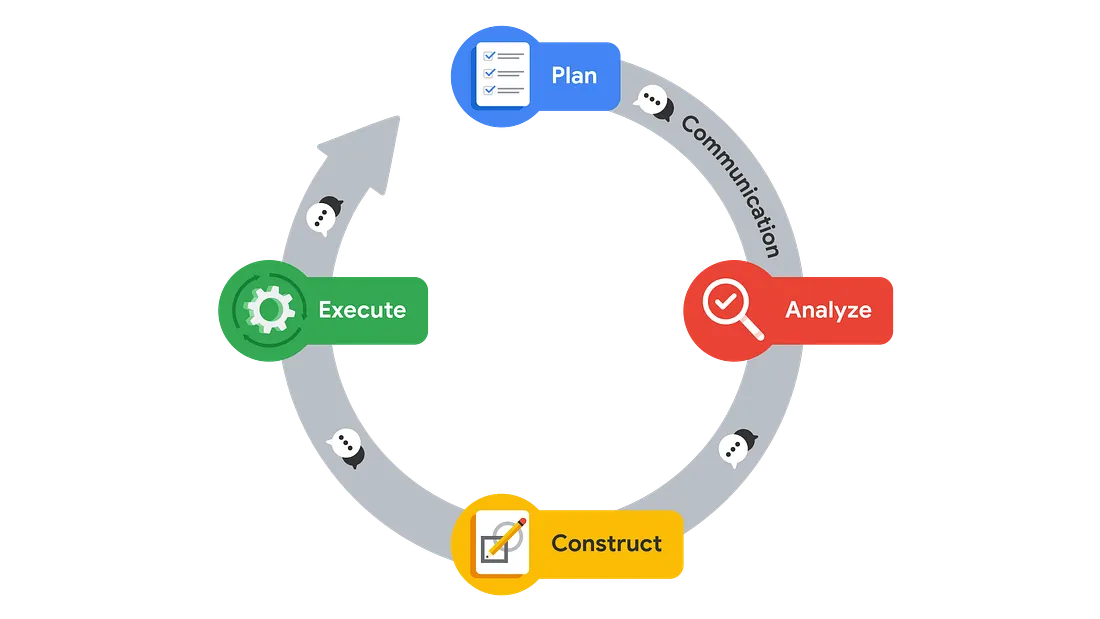

#paCe : Construct Stage

### We can complete this stage by covering these three main topics:

1. Select modeling approach
2. Build models
3. Build machine learning algorithms

### During this stage, Answering the question above by complete the following questions:

1. Identify the prediction task

2. Select the target variable and independent variables.

3. Prepare the data for modeling.

4. Divide the data into training and testing sets.

5. Select appropriate machine-learning algorithms.

6. Train a baseline model.

7. Train and compare multiple candidate models.

8. Check the relevant assumptions for each model.

9. Evaluate the models using suitable performance metrics.

10. Investigate overfitting, underfitting, class imbalance, and data leakage.

11. Improve the best-performing model.

12. Select the final model based on both performance and project requirements.

13. Document the modeling process, results, limitations, resources, and ethical considerations.

14. Save the final model and preprocessing pipeline for the Execute stage.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder , OneHotEncoder, MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split ,GridSearchCV
import lightgbm as lgm
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC ,SMOTE
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay , accuracy_score, f1_score , recall_score , precision_score , classification_report
from imblearn.pipeline import Pipeline

# We will divide the Construt Stage into two independent stages of training models

1. Predicting the when the machine can fail on specifics values

2. Predicting the Type Of Machine Failure

# 1. Predicting the when the machine can fail on specifics values

In [131]:
df = pd.read_csv("df_cleaned.csv",index_col=0)

In [132]:
df.head(5)

,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF]
UDI,,,,,,,,,,,,,
1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


# Feature Engineering

In [133]:
df['Power[W]'] = round(df['Torque_[Nm]'] * (df['Rotational_speed_[rpm]'] * (2 * np.pi / 60)),2)
df['strain'] = df['Tool_wear_[min]'] * df['Torque_[Nm]']
df['Temperature_difference'] = df['Process_temperature_[K]'] - df['Air_temperature_[K]']

In [134]:
df.sample(10)

,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,,
3120,L90664,L,299.6,309.7,1396,35.7,104,0,0,0,0,0,0,5218.94,3712.8,10.1
1824,M60281,M,298.7,308.9,1377,49.6,49,0,0,0,0,0,0,7152.28,2430.4,10.2
6870,H21091,H,298.4,308.1,1588,35.9,55,0,0,0,0,0,0,5969.99,1974.5,9.7
2960,M98529,M,301.0,313.0,1488,34.1,150,0,0,0,0,0,0,5313.56,5115.0,12.0
5294,L90570,L,298.8,307.7,1555,35.3,214,0,0,0,0,0,0,5748.22,7554.2,8.9
3972,L93481,L,300.4,311.3,1550,36.8,43,0,0,0,0,0,0,5973.21,1582.4,10.9
5124,L87281,L,298.6,308.1,1621,60.1,100,0,0,0,0,0,0,10202.02,6010.0,9.5
5542,M61761,M,303.0,314.0,1649,55.6,162,0,0,0,0,0,0,9601.17,9007.2,11.0
2968,L85453,L,304.3,313.7,1302,48.5,210,1,1,0,0,0,0,6612.74,10185.0,9.4


In [135]:
df_copy_machine_failure = df.copy()
df_copy_machine_type_failure = df.copy()

In [136]:
df_copy_machine_failure.drop(columns=["Product_ID"],inplace=True)

In [137]:
df_copy_machine_failure.sample(5)

,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,
7742,L,300.6,313.0,1632,43.0,35,0,0,0,0,0,0,7348.81,1505.0,12.4
1070,L,301.2,311.0,1631,55.3,131,0,0,0,0,0,0,9445.13,7244.3,9.8
8202,L,301.2,311.3,1485,29.2,180,0,0,0,0,0,0,4540.86,5256.0,10.1
1908,L,300.4,309.3,1788,39.7,133,0,0,0,0,0,0,7433.39,5280.1,8.9
7375,L,300.9,308.8,1514,38.7,46,0,0,0,0,0,0,6135.72,1780.2,7.9


In [138]:
X = df_copy_machine_failure.drop(columns=["Machine_failure","Tool_Wear_Failure[TWF]","Heat_Dissipation_Failure[HDF]","Power_Failure[PWF]","Overstrain_Failure[OSF]","Random_Failures[RNF]"])
y = df_copy_machine_failure["Machine_failure"]

In [139]:
X_train_mf, X_test_mf, y_train_mf, y_test_mf = train_test_split(X, y, test_size=0.20, random_state=42)

In [140]:
numerical_data_mf = X.select_dtypes(include=np.number)
categorical_data_mf = X.select_dtypes(include="object")

In [141]:
numerical_feature = Pipeline(steps=[
    ("scaler",StandardScaler())
])


In [142]:
categorical_feature = Pipeline(steps=[
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [143]:
Processor = ColumnTransformer(transformers=[
    ("numerical",numerical_feature,numerical_data_mf.columns),
    ("categorical",categorical_feature,categorical_data_mf.columns)
])

In [144]:
models = [LogisticRegression(),RandomForestClassifier(),lgm.LGBMClassifier(),XGBClassifier()]
models_names = ["LogisticRegression","RandomForestClassifier","LGBMClassifier","XGBClassifier"]

In [145]:
pipes = [Pipeline(steps=[("processor",Processor),("model",model)]) for model in models]
# pipes[3].get_params()

In [146]:
scale_pos_weight = len(df_copy_machine_failure[df_copy_machine_failure['Machine_failure']==0])//len(df_copy_machine_failure[df_copy_machine_failure['Machine_failure']==1])
scale_pos_weight

14

In [147]:

params=[{"model__multi_class":["multinomial",'ovr','deprecated'],"model__penalty":['l2','l1'],"model__class_weight":["balanced"],"model__max_iter":[1000]},

        {"model__n_estimators":[200,300,500],"model__criterion":['gini','entropy'],"model__class_weight":["balanced","balanced_subsample"],"model__random_state":[42]} ,

        {"model__n_estimators":[100,300,500],"model__boosting_type":['gbdt','goss','dart','rf'],"model__learning_rate":[0.05,0.01],"model__importance_type":['split','gain'],"model__class_weight":["balanced"]},

        {"model__n_estimators":[100,200,300],"model__learning_rate":[0.01,0.05,0.1],"model__booster":['gbtree','gblinear','dart'],"model__scale_pos_weight":[scale_pos_weight]}
        ]

In [148]:
grids = [GridSearchCV(estimator=pipes[i],param_grid=params[i],cv=2) for i in range(len(pipes))]

In [149]:
for i in range(len(grids)):
    grids[i].fit(X_train_mf,y_train_mf)

    print(f"model {models_names[i]} has {grids[i].best_score_}")

model LogisticRegression has 0.80825
model RandomForestClassifier has 0.981875
[LightGBM] [Info] Number of positive: 251, number of negative: 3749
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 250, number of negative: 3750
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1612
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [I

In [150]:
f1_scores = [f1_score(y_test_mf,grids[i].predict(X_test_mf)) for i in range(len(grids))]
recall_scores = [recall_score(y_test_mf,grids[i].predict(X_test_mf)) for i in range(len(grids))]
precision_scores = [precision_score(y_test_mf,grids[i].predict(X_test_mf)) for i in range(len(grids))]
accuracy_scores = [accuracy_score(y_test_mf,grids[i].predict(X_test_mf)) for i in range(len(grids))]

FDR = [1 - precision_scores[i] for i in range(len(precision_scores))]

metrics_models_table = pd.DataFrame({"models":models_names,
                                     "f1_scores":f1_scores,
                                     "recall_scores":recall_scores,
                                     "precision_scores":precision_scores,
                                     "accuracy_scores":accuracy_scores,"FDR":FDR})

metrics_models_table

,models,f1_scores,recall_scores,precision_scores,accuracy_scores,FDR
0,LogisticRegression,0.356688,0.817518,0.228106,0.7980,0.771894
1,RandomForestClassifier,0.883534,0.802920,0.982143,0.9855,0.017857
2,LGBMClassifier,0.875000,0.817518,0.941176,0.9840,0.058824
3,XGBClassifier,0.846154,0.802920,0.894309,0.9800,0.105691


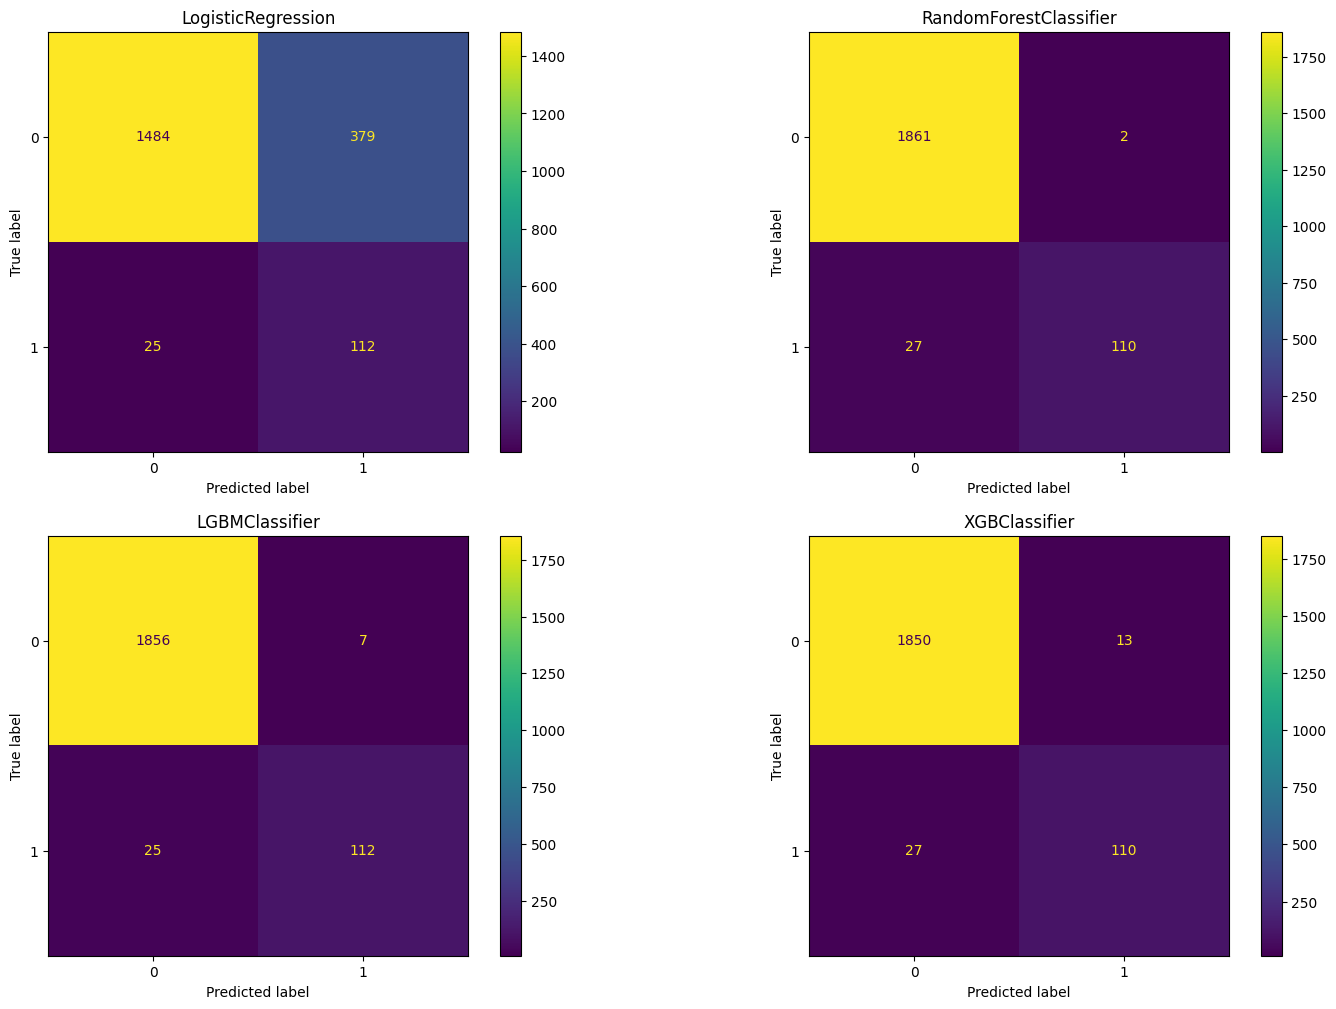

In [151]:
fig , ax = plt.subplots(2,2,figsize=(18,12))
for i in range(len(grids)):
  ax[i//2,i%2].set_title(f"{models_names[i]}")
  ConfusionMatrixDisplay(confusion_matrix(y_test_mf,grids[i].predict(X_test_mf))).plot(ax=ax[i//2,i%2])
plt.show()

In [211]:
reports  = [classification_report(y_test_mf, grids[i].predict(X_test_mf), target_names=['Non_Failure','Failure'], zero_division=0,output_dict=True) for i in range(len(grids)) ]

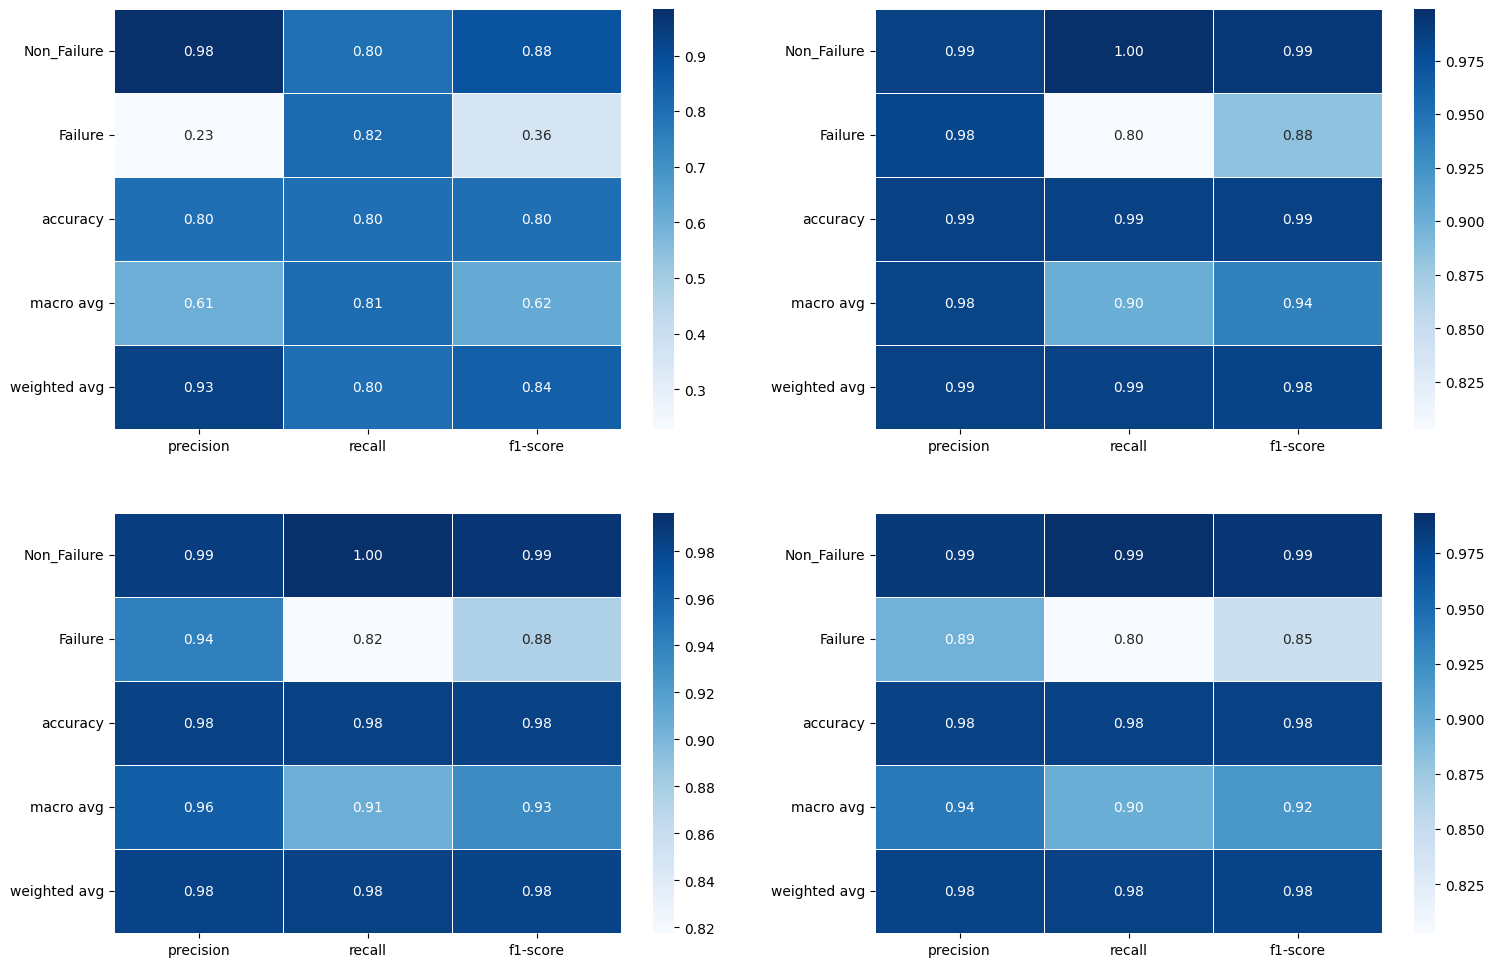

In [214]:
figure , axis = plt.subplots(2,2,figsize=(18,12))
for j in range(len(reports)):
  report_df = pd.DataFrame(report[j]).transpose()

# Remove support because it's on a different scale
  report_df = report_df.drop(columns=["support"])

  sns.heatmap(
    report_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    ax=axis[j//2,j%2]
  )
plt.show()

# 2.  Now will will predict the Type Of Mchine Failure

In [152]:
df_copy_machine_type_failure.drop(columns=["Product_ID"],inplace=True)

In [153]:
df_copy_machine_type_failure.head()

,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,
1,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0,3241.86,4831.4,9.2
2,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0,4681.31,8042.7,9.2
3,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0,7443.00,2432.1,9.1
4,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0,4944.99,11606.4,9.4
5,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0,7530.59,5133.8,10.9


In [154]:
df_copy_machine_type_failure = df_copy_machine_type_failure[df_copy_machine_type_failure['Machine_failure'] == 1 ]
df_copy_machine_type_failure.head()

,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,
4,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0,4944.99,11606.4,9.4
11,L,301.2,309.5,1165,34.6,92,1,0,1,0,0,0,4221.15,3183.2,8.3
13,M,298.8,306.8,1332,20.9,139,1,0,1,0,0,0,2915.27,2905.1,8.0
23,L,295.5,306.1,1524,57.0,245,1,0,0,0,1,0,9096.80,13965.0,10.6
54,M,299.0,307.4,1161,43.4,37,1,0,1,0,0,0,5276.56,1605.8,8.4


In [155]:
X_t = df_copy_machine_type_failure.drop(columns=["Tool_Wear_Failure[TWF]","Heat_Dissipation_Failure[HDF]","Power_Failure[PWF]","Overstrain_Failure[OSF]","Random_Failures[RNF]"])
y_t = df_copy_machine_type_failure[["Tool_Wear_Failure[TWF]",	"Heat_Dissipation_Failure[HDF]"	,"Power_Failure[PWF]","Overstrain_Failure[OSF]","Random_Failures[RNF]"]]

In [156]:
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(X_t, y_t, test_size=0.20, random_state=42)

In [157]:
numerical_data_type_failure = X_t.select_dtypes(include=np.number)
categorical_data_type_failure = y_t.select_dtypes(include="object")

In [158]:
Processor_tf = ColumnTransformer(transformers=[
    ("numerical",numerical_feature,numerical_data_type_failure.columns),
    ("categorical",categorical_feature,categorical_data_type_failure.columns)
])

In [159]:
pipes_tf = Pipeline(steps=[
    ("processor",Processor),
    ("model",MultiOutputClassifier(XGBClassifier(class_weight='balanced')))
])

model_tf = pipes_tf.fit(X_train_tf,y_train_tf)


In [164]:
X_test_tf.iloc[124:125,:]

,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Power[W],strain,Temperature_difference
UDI,,,,,,,,,,
2687,L,296.8,306.3,1595,63.1,243,1,10539.47,15333.3,9.5


In [ ]:
predict_tf = model_tf.predict(X_test_tf)
predict_tf

In [184]:
acc_tf = accuracy_score(y_test_tf,predict_tf)
f1_score_tf = f1_score(y_test_tf,predict_tf,average='weighted')
recall_score_tf = recall_score(y_test_tf,predict_tf,average='weighted')
precision_score_tf = precision_score(y_test_tf,predict_tf,average='weighted')
FDR_tf = 1 - precision_score_tf

metrics_Failue_type_table = pd.DataFrame({"Model_name":"XGBClassifier",
                                          "accuracy_of_Failure_Type":acc_tf,
                                          "F1-Score_of_Failure_Type":f1_score_tf,
                                          "recall_score_Of_Failure_Type":recall_score_tf,
                                          "precision_score_Of_Failure_Type":precision_score_tf,
                                          "FDR_Of_Failure_Type":FDR_tf},index=[0])
metrics_Failue_type_table

,Model_name,accuracy_of_Failure_Type,F1-Score_of_Failure_Type,recall_score_Of_Failure_Type,precision_score_Of_Failure_Type,FDR_Of_Failure_Type
0,XGBClassifier,0.898438,0.943756,0.914894,0.986288,0.013712


In [216]:
report_tf = classification_report(y_test_tf,predict_tf,target_names=["Tool_Wear_Failure[TWF]",	"Heat_Dissipation_Failure[HDF]"	,"Power_Failure[PWF]","Overstrain_Failure[OSF]","Random_Failures[RNF]"],zero_division=0,output_dict=True)

In [217]:
df_report_tf = pd.DataFrame(report_tf).transpose()
df_report_tf

,precision,recall,f1-score,support
Tool_Wear_Failure[TWF],1.000000,0.727273,0.842105,44.0
Heat_Dissipation_Failure[HDF],1.000000,1.000000,1.000000,34.0
Power_Failure[PWF],1.000000,1.000000,1.000000,5.0
Overstrain_Failure[OSF],0.966667,1.000000,0.983051,58.0
Random_Failures[RNF],0.000000,0.000000,0.000000,0.0
micro avg,0.984733,0.914894,0.948529,141.0
macro avg,0.793333,0.745455,0.765031,141.0
weighted avg,0.986288,0.914894,0.943756,141.0
samples avg,0.980469,0.945312,0.955729,141.0
